In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

BASE_URL = "http://localhost:8000"

def upload_eeg_file(file_path, state=None):
    """
    Загрузка EDF файла в базу данных
    
    Параметры:
    file_path: str - путь к файлу
    state: str - состояние записи ('rest', 'load', 'recovery')
    """
    with open(file_path, 'rb') as f:
        files = {'file': (file_path, f, 'application/octet-stream')}
        data = {'state': state} if state else {}
        response = requests.post("http://localhost:8000/upload/", files=files, data=data)
    return response.json()

def get_eeg_data(record_id):
    """Получение данных EEG из базы данных"""
    response = requests.get(f"{BASE_URL}/records/{record_id}/data")
    return np.array(response.json()['data'])


def plot_eeg_data(data, sample_rate=1000, channels=None):
    """
    Построение графика EEG данных.
    
    Параметры:
    data         - ndarray формы (n_channels, n_samples)
    sample_rate  - частота дискретизации (Гц)
    channels     - список индексов каналов, которые нужно отобразить (0-based).
                   Если None, отображаются все каналы.
    """
    if channels is None:
        channels_to_plot = list(range(data.shape[0]))
    else:
        channels_to_plot = channels

    time = np.arange(data.shape[1]) / sample_rate

    plt.figure(figsize=(15, 8))
    for i in channels_to_plot:
        plt.plot(time, data[i], label=f'Channel {i+1}')

    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('EEG Signals')
    plt.legend()
    plt.grid(True)
    plt.show()

In [34]:
# 1
# result = upload_eeg_file("Data/01/2025-03-17_10.34.edf", "rest")
# result = upload_eeg_file("Data/01/2025-03-17_10.39.edf", "load")
# result = upload_eeg_file("Data/01/2025-03-17_10.49.edf", "recovery")

# 2
# result = upload_eeg_file("Data/02/2025-03-17_10.00.edf", "rest")
# result = upload_eeg_file("Data/02/2025-03-17_10.08.edf", "load")
# result = upload_eeg_file("Data/02/2025-03-17_10.18.edf", "recovery")

# 3
# result = upload_eeg_file("Data/03/2025-03-17_09.30.edf", "recovery")

# 5
# result = upload_eeg_file("Data/05/2025-03-17_08.15.edf", "rest")
# result = upload_eeg_file("Data/05/2025-03-17_08.21.edf", "load")
# result = upload_eeg_file("Data/05/2025-03-17_08.32.edf", "recovery")

In [7]:
# resp = requests.delete(BASE_URL + "/records/" + str(2))

In [2]:
resp = requests.get(BASE_URL + "/records/")
resp.raise_for_status()
df = pd.DataFrame(resp.json())
df

,filename,id,created_at,updated_at
0,Data/01/2025-03-17_10.34.edf,3,2025-05-16T14:42:37.459618,2025-05-16T14:42:37.459622
1,Data/01/2025-03-17_10.39.edf,4,2025-05-16T14:42:37.824384,2025-05-16T14:42:37.824390
2,Data/01/2025-03-17_10.49.edf,5,2025-05-16T14:42:38.682229,2025-05-16T14:42:38.682233
3,Data/02/2025-03-17_10.00.edf,6,2025-05-16T14:55:13.659588,2025-05-16T14:55:13.659592
4,Data/02/2025-03-17_10.08.edf,7,2025-05-16T14:55:14.137705,2025-05-16T14:55:14.137708
5,Data/02/2025-03-17_10.18.edf,8,2025-05-16T14:55:14.881574,2025-05-16T14:55:14.881579
6,Data/05/2025-03-17_08.15.edf,9,2025-05-16T15:00:02.754146,2025-05-16T15:00:02.754151
7,Data/05/2025-03-17_08.21.edf,10,2025-05-16T15:00:03.082002,2025-05-16T15:00:03.082006
8,Data/05/2025-03-17_08.32.edf,11,2025-05-16T15:00:03.835722,2025-05-16T15:00:03.835726
9,Data/03/2025-03-17_09.30.edf,12,2025-05-16T15:02:15.742071,2025-05-16T15:02:15.742076


(6, 245000)


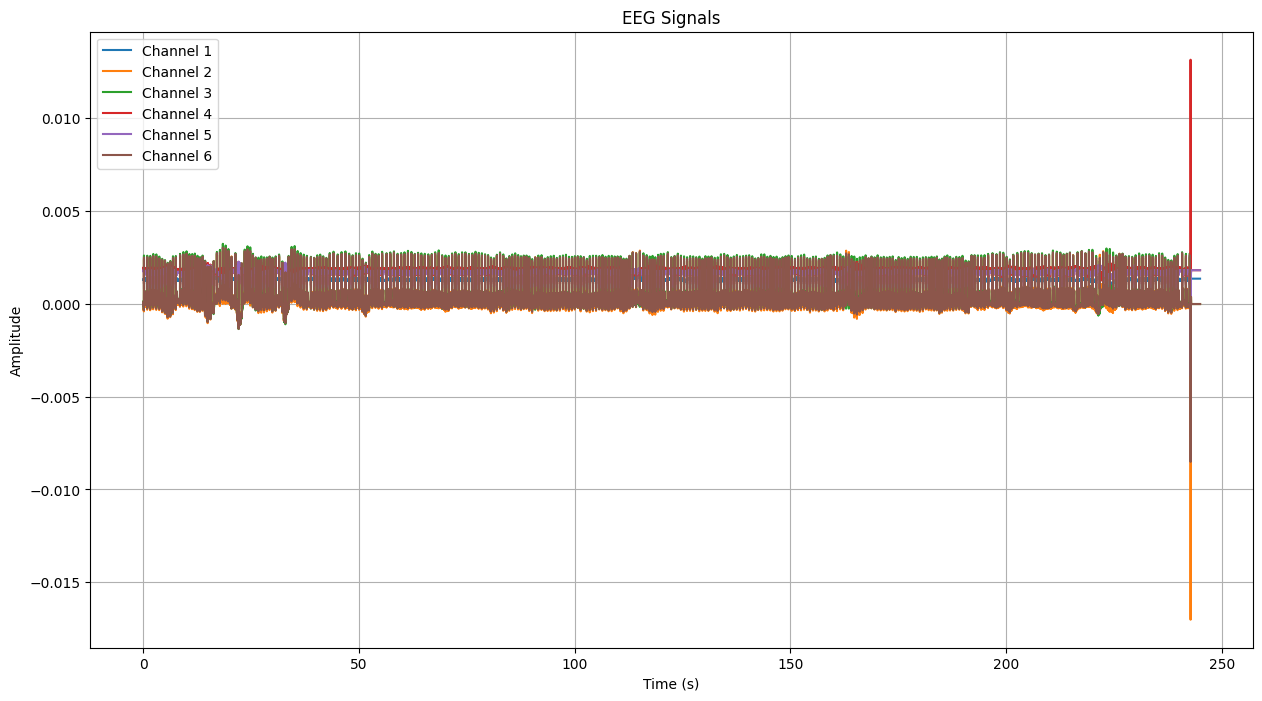

In [3]:
data = get_eeg_data(5)
print(data.shape)
plot_eeg_data(data)